In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load Data
df = pd.read_csv('/content/drive/MyDrive/Data 102/Data/U.S._Chronic_Disease_Indicators__CDI___2023_Release.csv')

/tmp/ipython-input-1796281485.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Data 102/Data/U.S._Chronic_Disease_Indicators__CDI___2023_Release.csv')


In [5]:
# Define Variables Mapping
target_questions = {
    # Outcome
    'Outcome': 'Prevalence of chronic obstructive pulmonary disease among adults >= 18',

    # Primary Policy Variable
    'Treatment': 'Proportion of the population protected by a comprehensive smoke-free policy prohibiting smoking in all indoor areas of workplaces and public places, including restaurants and bars',

    # Confounders
    'Gini': 'Gini Index of income inequality',
    'Rural_Culture': 'Current smokeless tobacco use among adults aged >= 18 years',
    'Professional_Class': 'Visits to dentist or dental clinic among adults aged >= 18 years',
    'Age_Labor': 'Arthritis among adults aged >= 18 years'
}

In [6]:
# Filter and Clean
subset = df[df['Question'].isin(target_questions.values())].copy()
subset['DataValue'] = pd.to_numeric(subset['DataValue'], errors='coerce')

if 'Stratification1' in subset.columns:
    subset = subset[subset['Stratification1'] == 'Overall']

In [7]:
# Pivot
df_wide = subset.pivot_table(
    index=['LocationAbbr', 'YearStart'],
    columns='Question',
    values='DataValue'
).reset_index()

question_map = {v: k for k, v in target_questions.items()}
df_wide.columns = [question_map.get(col, col) for col in df_wide.columns]

In [11]:
df_wide['YearStart'].sort_values(ascending= True).value_counts()

,count
YearStart,
2019,55
2020,55
2021,55
2016,55
2017,54
2013,54
2012,54
2011,54
2014,54


EDA

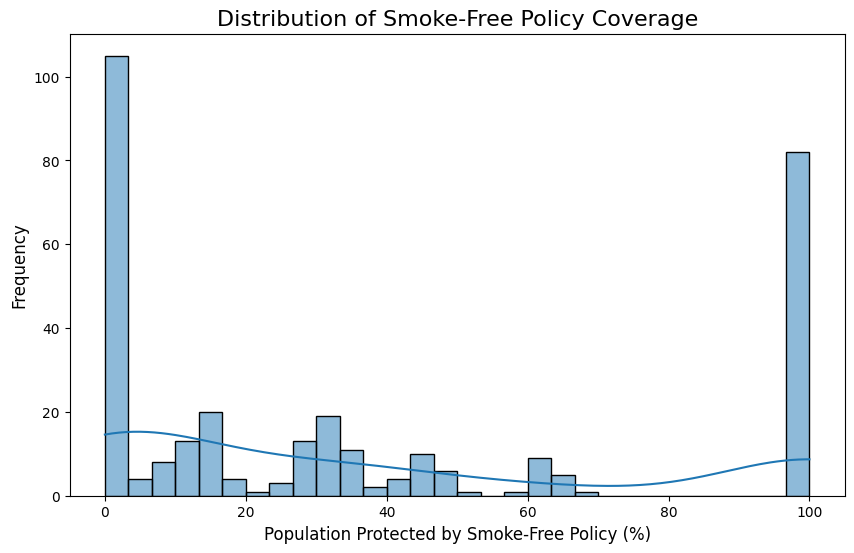

In [ ]:
# Plot 1: Histogram of the Treatment variable (Policy Coverage)
if 'Treatment' in df_wide.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_wide['Treatment'].dropna(), kde=True, bins=30)
    plt.title('Distribution of Smoke-Free Policy Coverage', fontsize=16)
    plt.xlabel('Population Protected by Smoke-Free Policy (%)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.savefig('policy_coverage_distribution.png')
    plt.show()
else:
    print(f"Warning: Could not plot. Column '{Treatment}' not in df_wide.")

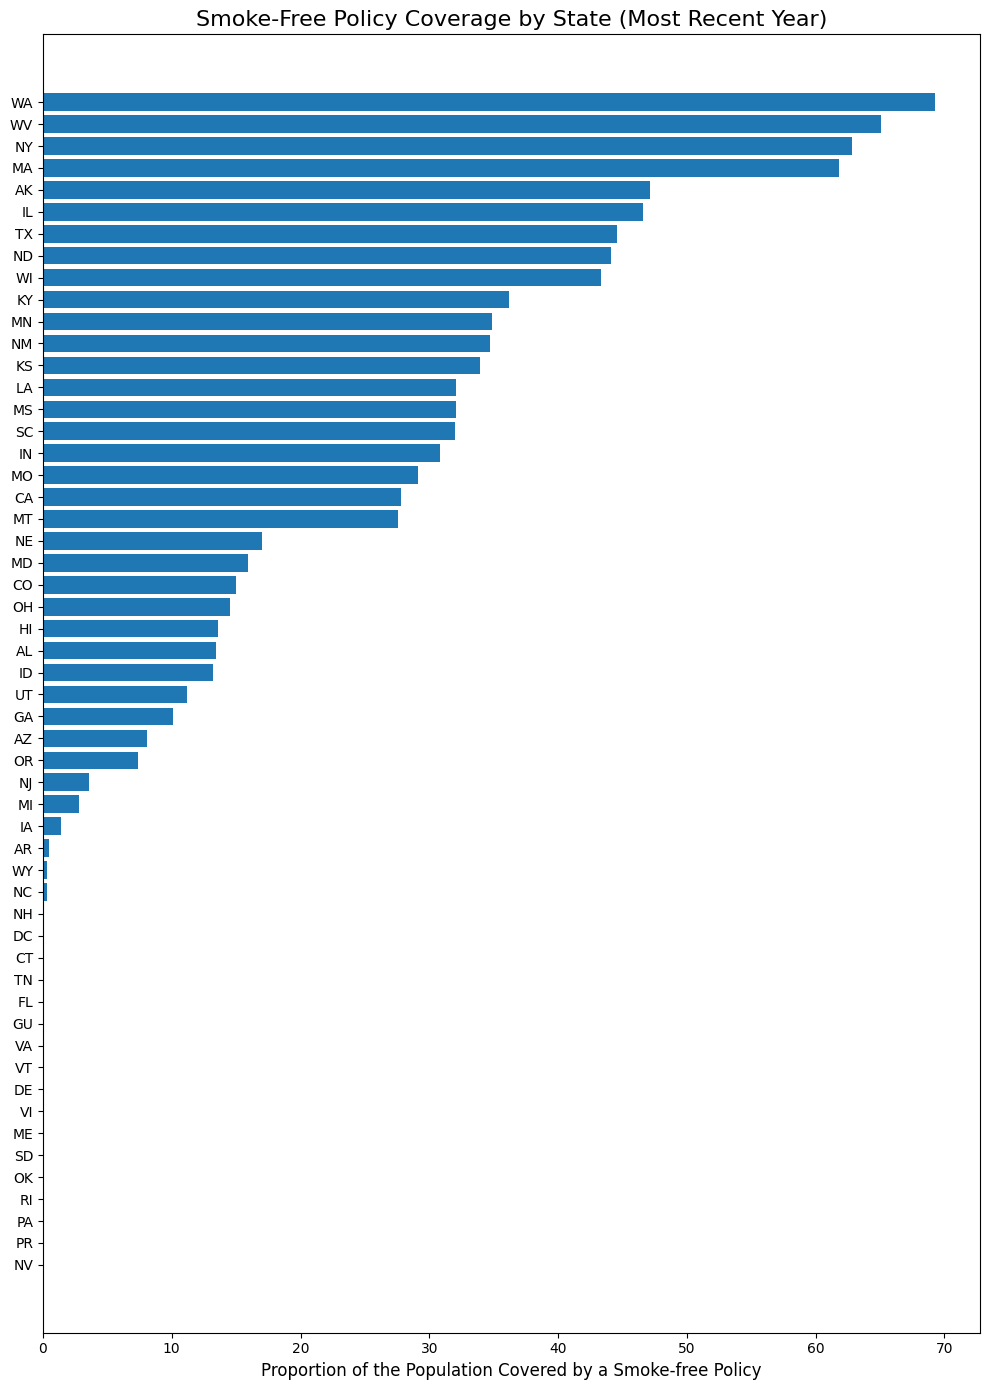

In [ ]:
# Plot 2: Histogram of Coverage per State (Based on the latest observation)

# Sorting by year and grouping by location, to obtain most recent coverage:
df_latest = df_wide.sort_values('YearStart').groupby('LocationAbbr').tail(1)
df_latest = df_latest.sort_values('Treatment', ascending=True)
df_latest = df_latest[df_latest['LocationAbbr'] != 'US']
df_latest

# Plotting coverage by state:
plt.figure(figsize=(10, 14))
plt.barh(df_latest["LocationAbbr"], df_latest['Treatment'])
plt.xlabel('Proportion of the Population Covered by a Smoke-free Policy', fontsize=12)
plt.title("Smoke-Free Policy Coverage by State (Most Recent Year)", fontsize=16)
plt.tight_layout()
plt.show()

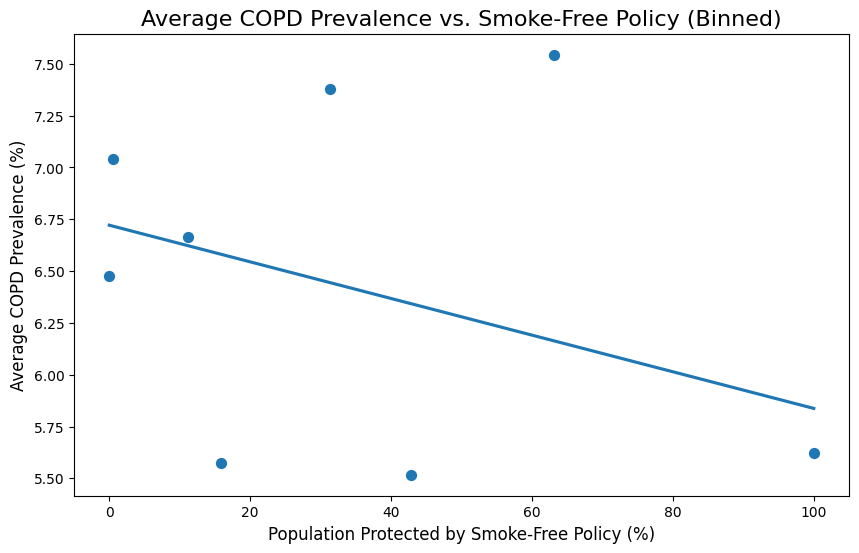

In [ ]:
# Plot 3: Binned Scatterplot of Treatment vs. Outcome
# We use regplot, but specify x_bins=10.
# This will group the x-data into 10 bins and plot the average y for each.
# We also add a simple linear regression line (order=1).
plt.figure(figsize=(10, 6))
sns.regplot(
    x=df_wide['Treatment'],
    y=df_wide['Outcome'],
    x_bins=10,  # This is the key parameter!
    order=1,    # Fit a simple linear trend
    ci=None     # Turn off the confidence interval for a cleaner look
)
plt.title('Average COPD Prevalence vs. Smoke-Free Policy (Binned)', fontsize=16)
plt.xlabel('Population Protected by Smoke-Free Policy (%)', fontsize=12)
plt.ylabel('Average COPD Prevalence (%)', fontsize=12)
plt.savefig('binned_treatment_vs_outcome.png')
plt.show()

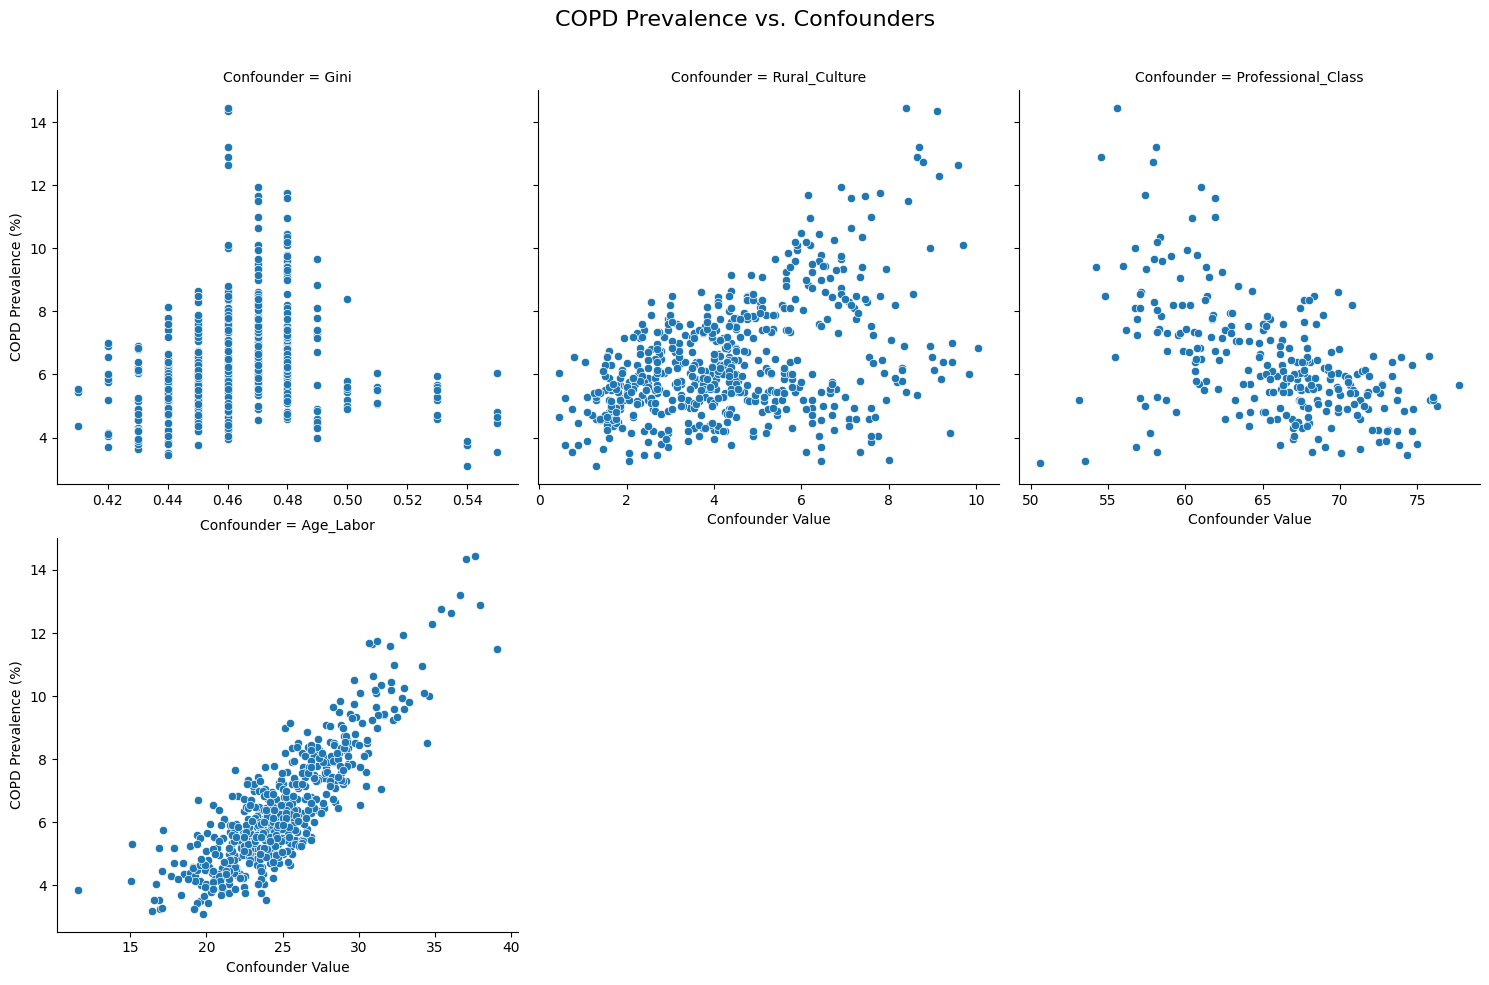

In [ ]:
# Storing list of confounders:
confounders = [
    'Gini',
    'Rural_Culture',
    'Professional_Class',
    'Age_Labor'
]

# Melt the dataframe to long format
df_long = df_wide.melt(
    id_vars=['LocationAbbr', 'YearStart', 'Outcome'],
    value_vars=confounders,
    var_name='Confounder',
    value_name='ConfounderValue'
)

g = sns.relplot(
    data=df_long.dropna(subset=['ConfounderValue', 'Outcome']),
    x='ConfounderValue',
    y= 'Outcome',
    col='Confounder',
    col_wrap=3,
    kind='scatter',
    facet_kws={'sharex': False, 'sharey': True}
)

g.set_axis_labels("Confounder Value", "COPD Prevalence (%)")
plt.subplots_adjust(top=0.9)
plt.suptitle("COPD Prevalence vs. Confounders", fontsize=16)
plt.show()

Interpolation:

In [ ]:
# Reindex & Interpolate
states = df_wide['LocationAbbr'].unique()
years = range(df_wide['YearStart'].min(), df_wide['YearStart'].max() + 1)
full_index = pd.MultiIndex.from_product([states, years], names=['LocationAbbr', 'YearStart'])
df_final = df_wide.set_index(['LocationAbbr', 'YearStart']).reindex(full_index).reset_index()

# Interpolation: Policy (Forward Fill), Others (Linear)
df_final['Treatment'] = df_final.groupby('LocationAbbr')['Treatment'].ffill()

for col in ['Outcome', 'Gini', 'Asthma', 'Rural_Culture', 'Professional_Class', 'Age_Labor']:
    if col in df_final.columns:
        df_final[col] = df_final.groupby('LocationAbbr')[col].transform(
            lambda x: x.interpolate(method='linear', limit_direction='both')
        )

df_final = df_final.dropna()

In [ ]:
# Run the Final OLS Model
predictors = ['Treatment', 'Gini', 'Rural_Culture', 'Professional_Class', 'Age_Labor']
X = df_final[predictors]
Y = df_final['Outcome']

X = sm.add_constant(X)
model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Outcome   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     434.7
Date:                Fri, 12 Dec 2025   Prob (F-statistic):          2.69e-173
Time:                        22:47:27   Log-Likelihood:                -549.70
No. Observations:                 474   AIC:                             1111.
Df Residuals:                     468   BIC:                             1136.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -3.4231      1